<a href="https://colab.research.google.com/github/AthulkrishnaR/-LinearRegression--2/blob/main/l3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score


In [14]:
data ={
    'Area' :[1200,1500,1800,-2400,3000,
             3500,4000,4500,5000,5500],
    'Bedrooms': [2,3,3,4,5,
                 5,6,6,7,7],
    'Age' : [10,5,8,2,1,3,2,1,2,3],
    'Distance' : [5,3,4,2,1,
                  2,1,3,2,1],
    'price' : [250,320,340,450,600,650,700,720,800,850]
}
df=pd.DataFrame(data)
print(df)

   Area  Bedrooms  Age  Distance  price
0  1200         2   10         5    250
1  1500         3    5         3    320
2  1800         3    8         4    340
3 -2400         4    2         2    450
4  3000         5    1         1    600
5  3500         5    3         2    650
6  4000         6    2         1    700
7  4500         6    1         3    720
8  5000         7    2         2    800
9  5500         7    3         1    850


In [16]:
X = df[['Area','Bedrooms','Age','Distance']]
Y =df['price']

In [19]:
model =LinearRegression()
model.fit(X,Y)
y_pred = model.predict(X)

In [21]:
print("\nModel PARAMETRs\n")

print("Intercept")
print(model.intercept_)

print("\nCoefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(feature,":", coef)


Model PARAMETRs

Intercept
31.19019705225196

Coefficients:
Area : 0.007493242359374025
Bedrooms : 110.18895887596194
Age : -0.3614633793784492
Distance : -4.767139193767221


In [23]:
print("\nREGRESSION EQUATION\n")
print("price=")
for feature,coef in zip(X.columns,model.coef_):
  print(f"({coef:.4f}*{feature})+")
print(model.intercept_)


REGRESSION EQUATION

price=
(0.0075*Area)+
(110.1890*Bedrooms)+
(-0.3615*Age)+
(-4.7671*Distance)+
31.19019705225196


In [24]:
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)
print("\nEVALUATION METRICS\n")
print("Mean sqared error (MSE):",mse)
print("R-sqaured error (R2):",(r2,4))


EVALUATION METRICS

Mean sqared error (MSE): 598.0413668429604
R-sqaured error (R2): (0.9854193152222801, 4)


In [25]:
new_house=pd.DataFrame({
    'Area':[2800],
    'Bedrooms':[4],
    'Age':[2],
    'Distance':[2]
})

predicted_price = model.predict(new_house)
print("\nNEW HOUSE PREDICTION\n")
print("Predicted Price:",predicted_price[0])


NEW HOUSE PREDICTION

Predicted Price: 482.6699060160556


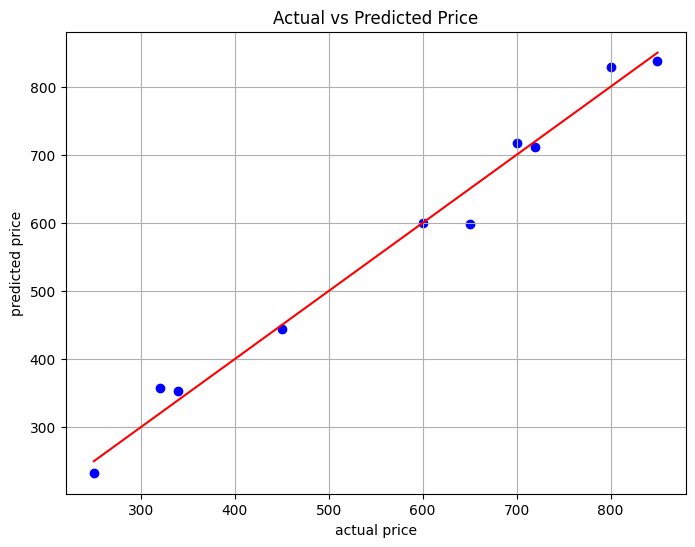

In [26]:
plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred, color='blue')
plt.plot([y.min(),y.max()],[y.min(),y.max()],color='red')
plt.xlabel('actual price')
plt.ylabel('predicted price')
plt.title('Actual vs Predicted Price')
plt.grid(True)
plt.show()